<a href="https://colab.research.google.com/github/GYULEE55/Breast-cancer_statistical_analysis/blob/main/%EC%9C%A0%EB%B0%A9%EC%95%94_%ED%85%8C%EC%9D%B4%EB%B8%942.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 기본 실행

In [ ]:
pip install lifelines

In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# 한글 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
# 메뉴 - 런타임 - 세션 다시 시작

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 36 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib -f
plt.rc("font", family="NanumGothic")  # 한글 폰트 지정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

#구글 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
plt.rc("font", family = "NanumGothic")
file_path ='/content/drive/MyDrive/세미1차/breast cancer DB2.csv'# 각자의 파일 경로 복
df1= pd.read_csv(file_path)


In [ ]:
df=df1.copy()
df.head()

,Sex,"Race recode (W, B, AI)",Age recode with <30-69,Marital status at diagnosis un,Grade,ER Status,PR Status,HER2,Survival month,Theraphy
0,Female,White,75-79 years,Divorced,Moderately differentiated; Grade II,Positive,Negative,Recode not available,14,No radiation and/or no surgery; unknown if sur...
1,Female,Black,70-74 years,Single (never married),Poorly differentiated; Grade III,Negative,Negative,Negative,12,Radiation after surgery
2,Female,White,70-74 years,Single (never married),Blank(s),Negative,Negative,Negative,59,Radiation after surgery
3,Female,White,60-64 years,Widowed,Unknown,Positive,Negative,Recode not available,81,No radiation and/or no surgery; unknown if sur...
4,Female,White,70-74 years,Widowed,Poorly differentiated; Grade III,Negative,Negative,Recode not available,7,No radiation and/or no surgery; unknown if sur...


In [ ]:
df.info() #데이터 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column                          Non-Null Count    Dtype 
---  ------                          --------------    ----- 
 0   Sex                             1048575 non-null  object
 1   Race recode (W, B, AI)          1048575 non-null  object
 2   Age recode with <30-69          1048575 non-null  object
 3   Marital status at diagnosis un  1048575 non-null  object
 4   Grade                           1048575 non-null  object
 5   ER Status                       1048575 non-null  object
 6   PR Status                       1048575 non-null  object
 7   HER2                            1048575 non-null  object
 8   Survival month                  1048575 non-null  object
 9   Theraphy                        1048575 non-null  object
dtypes: object(10)
memory usage: 80.0+ MB


In [ ]:
#열이름 재정립
df = df.rename(columns={          'Sex':'Sex',
                                  'Race recode (W, B, AI)':'Race',
                                 'Age recode with <30-69':'Age',
                                  'Marital status at diagnosis un':'Marital status',
                                  'Survival month':'Survival months'

                                  })
df.head()


,Sex,Race,Age,Marital status,Grade,ER Status,PR Status,HER2,Survival months,Theraphy
0,Female,White,75-79 years,Divorced,Moderately differentiated; Grade II,Positive,Negative,Recode not available,14,No radiation and/or no surgery; unknown if sur...
1,Female,Black,70-74 years,Single (never married),Poorly differentiated; Grade III,Negative,Negative,Negative,12,Radiation after surgery
2,Female,White,70-74 years,Single (never married),Blank(s),Negative,Negative,Negative,59,Radiation after surgery
3,Female,White,60-64 years,Widowed,Unknown,Positive,Negative,Recode not available,81,No radiation and/or no surgery; unknown if sur...
4,Female,White,70-74 years,Widowed,Poorly differentiated; Grade III,Negative,Negative,Recode not available,7,No radiation and/or no surgery; unknown if sur...


#데이터 전처리


In [ ]:
#데이터 전처리

## 생존기간 120보다 큰 거 지움

# Survival months 컬럼을 숫자형으로 변환(혹시 문자열이 있을 경우 대비)
df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# 120개월 초과하는 데이터 제거
df = df[df['Survival months'] <= 120]

# 결과 확인
print(df['Survival months'].describe())
print(f"120개월 초과 데이터가 제거된 후 데이터 개수: {len(df)}")

df.shape

##Race 그룹화


df['Race'].value_counts()

df['Race'].isnull().sum()

def group_race(x):
    if x == "White":
        return "White"
    elif x == "Asian or Pacific Islander":
        return "Asian or Pacific Islander"
    else:
        return "Other"

df['Race_group'] = df['Race'].apply(group_race)

# 결과 확인
print(df['Race_group'].value_counts())
print(df[['Race', 'Race_group']].head(10))

##Age

df['Age'].value_counts()

df['Age'].isnull().sum()

def age_group_from_range(age_str):
    if pd.isnull(age_str):
        return np.nan
    # '90+ years'와 같은 경우 숫자만 추출
    num_part = age_str.split('-')[0].split('+')[0]
    min_age = int(''.join(filter(str.isdigit, num_part)))
    if min_age < 50:
        return '<50'
    elif min_age < 60:
        return '<60'
    else:
        return '>=60'

df['Age_group'] = df['Age'].apply(age_group_from_range)

# 결과 확인
print(df['Age_group'].value_counts())
print(df[['Age', 'Age_group']].drop_duplicates().sort_values('Age'))



## Marital status

df['Marital status'].value_counts()

df['Marital status'].isnull().sum()

def group_marital_status(x):
    if x == "Married (including common law)":
        return "Married"
    elif x == "Single (never married)":
        return "Single"
    else:
        return "Other"

df['Marital_group'] = df['Marital status'].apply(group_marital_status)

# 결과 확인
print(df['Marital_group'].value_counts())
print(df[['Marital status', 'Marital_group']].drop_duplicates())

##Grade

df['Grade'].value_counts()
df['Grade'].isnull().sum()

def group_grade(x):
    if x == "Well differentiated; Grade I":
        return "Grade I"
    elif x == "Moderately differentiated; Grade II":
        return "Grade II"
    elif x == "Poorly differentiated; Grade III":
        return "Grade III"
    elif x == "Undifferentiated; anaplastic; Grade IV":
        return "Grade IV"
    else:
        return "Other"

df['Grade_group'] = df['Grade'].apply(group_grade)

# 결과 확인
print(df['Grade_group'].value_counts())
print(df[['Grade', 'Grade_group']].drop_duplicates())

## Estrogen_Status



df['ER Status'].value_counts()

df['ER Status'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['ER_group'] = df['ER Status'].apply(group_er_status)

# 결과 확인
print(df['ER_group'].value_counts())
print(df[['ER Status', 'ER_group']].drop_duplicates())



##Progesterone_Status

df['PR Status'].value_counts()

df['PR Status'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['PR_group'] = df['PR Status'].apply(group_er_status)

# 결과 확인
print(df['PR_group'].value_counts())
print(df[['PR Status', 'PR_group']].drop_duplicates())



## HER2

df['HER2'].value_counts()

df['HER2'].isnull().sum()

# Positive, Negative, 그 외는 Other로 그룹화
def group_er_status(x):
    if x == "Positive":
        return "Positive"
    elif x == "Negative":
        return "Negative"
    else:
        return "Other"

df['HER2'] = df['HER2'].apply(group_er_status)

# 결과 확인
print(df['HER2'].value_counts())
print(df[['HER2', 'HER2']].drop_duplicates())



##therapy

def group_radiation(x):
    if x == "No radiation and/or no surgery; unknown if surgery and/or radiation given":
        return "N Radiation"
    elif x == "Intraoperative radiation":
        return "Other"
    else:
        return "Y Radiation"

df['Radiation_group'] = df['Theraphy'].apply(group_radiation)

# 결과 확인
print(df['Radiation_group'].value_counts())
print(df[['Theraphy', 'Radiation_group']].drop_duplicates())


count    692838.000000
mean         50.969895
std          34.649969
min           0.000000
25%          20.000000
50%          47.000000
75%          79.000000
max         120.000000
Name: Survival months, dtype: float64
120개월 초과 데이터가 제거된 후 데이터 개수: 692838
Race_group
White                        549365
Asian or Pacific Islander     73713
Other                         69760
Name: count, dtype: int64
     Race Race_group
0   White      White
1   Black      Other
2   White      White
3   White      White
4   White      White
6   White      White
7   White      White
9   White      White
11  White      White
12  White      White
Age_group
>=60    430997
<60     139934
<50     121907
Name: count, dtype: int64
                Age Age_group
76580   01-04 years       <50
372859  05-09 years       <50
331927  10-14 years       <50
51571   15-19 years       <50
10851   20-24 years       <50
7778    25-29 years       <50
3310    30-34 years       <50
181     35-39 years       <50
9       40-44 ye

In [ ]:
##therapy

def group_radiation(x):
    if x == "No radiation and/or no surgery; unknown if surgery and/or radiation given":
        return "N Radiation"
    else:
        return "Y Radiation"

df['Radiation_group'] = df['Theraphy'].apply(group_radiation)

# 결과 확인
print(df['Radiation_group'].value_counts())
print(df[['Theraphy', 'Radiation_group']].drop_duplicates())


Radiation_group
N Radiation    383533
Y Radiation    309305
Name: count, dtype: int64
                                                Theraphy Radiation_group
0      No radiation and/or no surgery; unknown if sur...     N Radiation
1                                Radiation after surgery     Y Radiation
40                            Radiation prior to surgery     Y Radiation
58                              Intraoperative radiation     Y Radiation
199    Intraoperative rad with other rad before/after...     Y Radiation
3229                  Radiation before and after surgery     Y Radiation
27517              Sequence unknown, but both were given     Y Radiation
33601            Surgery both before and after radiation     Y Radiation


# 테이블 2 처리

In [ ]:
import pandas as pd
from scipy.stats import f_oneway  # ANOVA를 위한 SciPy 임포트 (필요 시 pip install scipy)

# 0. Survival months 필터링 (맨 처음 적용: 0 <= Survival months <= 120)
# 숫자형 변환 (문자열/이상값을 NaN으로 처리)
df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# 0 이상 120 이하인 데이터만 남김 (음수 및 120 초과 제거)
df = df[(df['Survival months'] >= 0) & (df['Survival months'] <= 120)]

# 결과 확인 (describe로 분포 확인 + 총 행 수)
print("\n🎯 Survival months 필터링 후 분포:")
print(df['Survival months'].describe())
print(f"🎯 Survival months 필터링 후 총 행 수: {df.shape[0]}")  # 이전 총 n(692838 등)에서 줄어든 값 출력

# 1. 주요 열의 고유 값 확인 (디버깅용: 필터링 전에 데이터 분포 확인)
print("\n🎯 주요 열의 고유 값 (unique):")
print("Sex unique:", df['Sex'].unique())
print("ER Status unique:", df['ER Status'].unique())
print("PR Status unique:", df['PR Status'].unique())
print("HER2 unique:", df['HER2'].unique())
print("Theraphy unique:", df['Theraphy'].unique())  # Radiation 그룹화 확인용

# 2. Radiation 그룹화 함수 정의 (원래 그대로)
def group_radiation(x):
    if x == "No radiation and/or no surgery; unknown if surgery and/or radiation given":
        return "N Radiation"
    elif x == "Intraoperative radiation":
        return "Other"
    else:
        return "Y Radiation"

# 3. 전체 df에 Radiation_group 열 생성 (Survival 필터링 후 적용)
df['Radiation_group'] = df['Theraphy'].apply(group_radiation)
print("\n🎯 Radiation_group 분포 (Survival 필터링 후 전체 df):")
print(df['Radiation_group'].value_counts())  # 이전 제공 값(N=383533 등)에서 Survival 필터링으로 변화 가능

# 4. 단계별 필터링: 각 단계 후 행 수 출력 (손실 지점 확인용)
# 단계 1: Sex == "Female" (대소문자 무시, 공백 제거)
df_temp = df[df['Sex'].str.strip().str.lower() == 'male']
print(f"🎯 단계 1: 여자(Female)만 필터링 후 행 수: {df_temp.shape[0]}")

# 단계 2: ER Status in ["Positive", "Negative"]
df_temp = df_temp[df_temp["ER Status"].str.strip().isin(["Positive", "Negative"])]
print(f"🎯 단계 2: ER Status 필터링 후 행 수: {df_temp.shape[0]}")

# 단계 3: PR Status in ["Positive", "Negative"]
df_temp = df_temp[df_temp["PR Status"].str.strip().isin(["Positive", "Negative"])]
print(f"🎯 단계 3: PR Status 필터링 후 행 수: {df_temp.shape[0]}")

# 단계 4: HER2 in ["Positive", "Negative"]
df_temp = df_temp[df_temp["HER2"].str.strip().isin(["Positive", "Negative"])]
print(f"🎯 단계 4: HER2 필터링 후 행 수: {df_temp.shape[0]}")

# 단계 5: Radiation_group == "Y Radiation" (이전 맥락에 맞춤. N을 원하시면 "N Radiation"으로 변경)
df_filtered = df_temp[df_temp["Radiation_group"] == "Y Radiation"]
print(f"🎯 단계 5: Y Radiation 필터링 후 최종 행 수: {df_filtered.shape[0]}")  # Survival 필터링으로 이전 값(218704 등)과 비슷해질 수 있음

# 5. 조합 문자열 생성 (필터링된 데이터프레임에서)
df_filtered['ER_PR_HER2'] = (
    'ER' + df_filtered['ER Status'].str.strip() + '/' +
    'PR' + df_filtered['PR Status'].str.strip() + '/' +
    'HER2' + df_filtered['HER2'].str.strip()
)

# 6. 관심 조합 목록 (ER+는 Positive, ER-는 Negative로 매핑)
target_combinations = {
    'ER+/PR+/HER2+': 'ERPositive/PRPositive/HER2Positive',
    'ER+/PR+/HER2-': 'ERPositive/PRPositive/HER2Negative',
    'ER-/PR-/HER2+': 'ERNegative/PRNegative/HER2Positive',
    'ER-/PR-/HER2-': 'ERNegative/PRNegative/HER2Negative'
}

# 7. 총 n 계산 (Y Radiation인 여자 총 수)
total_n = df_filtered.shape[0]
print(f"\n🎯 총 n (Y Radiation인 여자): {total_n}")

# 8. 각 조합별 n, %, Mean ± SD 계산 + ANOVA를 위한 그룹 데이터 수집
group_data = {}  # ANOVA를 위한 Survival months 리스트 저장
results = {}     # 테이블 결과를 위한 딕셔너리

for short_combo, full_combo in target_combinations.items():
    # 해당 조합의 서브 데이터프레임
    sub_df = df_filtered[df_filtered['ER_PR_HER2'] == full_combo]

    # n과 %
    n = sub_df.shape[0]
    percentage = (n / total_n * 100) if total_n > 0 else 0

    # Survival months의 Mean ± SD (NaN 제외)
    sm = sub_df['Survival months'].dropna()
    mean = sm.mean() if not sm.empty else float('nan')
    sd = sm.std() if not sm.empty else float('nan')

    # 결과 저장
    results[short_combo] = {
        'n': n,
        'percentage': percentage,
        'mean_sd': f"{mean:.2f} ± {sd:.2f}" if not pd.isna(mean) else "N/A"
    }

    # ANOVA를 위한 그룹 데이터 (비어 있지 않으면 추가)
    if not sm.empty:
        group_data[short_combo] = sm

# 9. ANOVA 수행 (4개 그룹의 Survival months 비교)
if len(group_data) == 4:  # 모든 그룹에 데이터가 있어야 함
    f_value, p_value = f_oneway(
        group_data['ER+/PR+/HER2+'],
        group_data['ER+/PR+/HER2-'],
        group_data['ER-/PR-/HER2+'],
        group_data['ER-/PR-/HER2-']
    )
    p_value_str = f"{p_value:.4f}" if p_value >= 0.0001 else "<0.0001"
else:
    f_value = float('nan')
    p_value_str = "N/A (그룹 데이터 부족)"
    print("⚠️ ANOVA 계산 불가: 일부 그룹에 Survival months 데이터가 없습니다.")

# 10. 테이블 형식 출력 (재계산된 결과)
print("\n🎯 재계산된 여자 + Y Radiation 조건의 ER/PR/HER2 조합별 SM Mean±SD, p-value, F-value")
print("Characteristic\t\tY Radiation(n={})\t\tSM Mean±SD\tp-value\tF-value".format(total_n))
print("-----------------------------------------------------------------------")
print("Female\tER+/PR+/HER2+\t{} ({}%)\t\t{}\t\t".format(results['ER+/PR+/HER2+']['n'], f"{results['ER+/PR+/HER2+']['percentage']:.2f}", results['ER+/PR+/HER2+']['mean_sd']))
print("\tER+/PR+/HER2-\t{} ({}%)\t\t{}\t\t".format(results['ER+/PR+/HER2-']['n'], f"{results['ER+/PR+/HER2-']['percentage']:.2f}", results['ER+/PR+/HER2-']['mean_sd']))
print("\tER-/PR-/HER2+\t{} ({}%)\t\t{}\t\t".format(results['ER-/PR-/HER2+']['n'], f"{results['ER-/PR-/HER2+']['percentage']:.2f}", results['ER-/PR-/HER2+']['mean_sd']))
print("\tER-/PR-/HER2-\t{} ({}%)\t\t{}\t\t{}\t{:.2f}".format(results['ER-/PR-/HER2-']['n'], f"{results['ER-/PR-/HER2-']['percentage']:.2f}", results['ER-/PR-/HER2-']['mean_sd'], p_value_str, f_value))
print("-----------------------------------------------------------------------")

# 11. 추가 확인: 필터링된 데이터의 Radiation_group 분포 및 매핑
print("\n🎯 필터링된 데이터의 Radiation_group 분포")
print(df_filtered['Radiation_group'].value_counts())

print("\n🎯 Theraphy와 Radiation_group 매핑 (중복 제거)")
print(df_filtered[['Theraphy', 'Radiation_group']].drop_duplicates())



🎯 Survival months 필터링 후 분포:
count    692838.000000
mean         50.969895
std          34.649969
min           0.000000
25%          20.000000
50%          47.000000
75%          79.000000
max         120.000000
Name: Survival months, dtype: float64
🎯 Survival months 필터링 후 총 행 수: 692838

🎯 주요 열의 고유 값 (unique):
Sex unique: ['Female' 'Male']
ER Status unique: ['Positive' 'Negative' 'Borderline/Unknown' 'Recode not available']
PR Status unique: ['Negative' 'Positive' 'Borderline/Unknown' 'Recode not available']
HER2 unique: ['Other' 'Negative' 'Positive']
Theraphy unique: ['No radiation and/or no surgery; unknown if surgery and/or radiation given'
 'Radiation after surgery' 'Radiation prior to surgery'
 'Intraoperative radiation'
 'Intraoperative rad with other rad before/after surgery'
 'Radiation before and after surgery'
 'Sequence unknown, but both were given'
 'Surgery both before and after radiation']

🎯 Radiation_group 분포 (Survival 필터링 후 전체 df):
Radiation_group
N Radiation    3835

/tmp/ipython-input-111-529288730.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['ER_PR_HER2'] = (


#테라피 테이블 3-1

#테라피 테이블3-2


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Create ER/PR/HER2 combination column (if not already present)
if 'ER_PR_HER2' not in df.columns:
    df['ER_PR_HER2'] = (
        'ER' + df['ER Status'].str.strip() + '/' +
        'PR' + df['PR Status'].str.strip() + '/' +
        'HER2' + df['HER2'].str.strip()
    )

# 2. Filter for females
female_df = df[df['Sex'].str.strip().str.lower() == 'female']
print(f"Filtered female rows: {female_df.shape[0]}")

# 3. Define target ER/PR/HER2 combinations
target_combinations = [
    'ERPositive/PRPositive/HER2Positive',  # ER+/PR+/HER2+
    'ERPositive/PRPositive/HER2Negative',  # ER+/PR+/HER2-
    'ERNegative/PRNegative/HER2Positive',  # ER-/PR-/HER2+
    'ERNegative/PRNegative/HER2Negative'   # ER-/PR-/HER2-
]

# 4. Filter to include only target combinations
filtered_df = female_df[female_df['ER_PR_HER2'].isin(target_combinations)]
print(f"Rows after filtering combinations: {filtered_df.shape[0]}")

# 5. Create crosstab: All Theraphy categories vs ER/PR/HER2 combinations
crosstab = pd.crosstab(filtered_df['Theraphy'], filtered_df['ER_PR_HER2'])

# Print crosstab for review
print("\nCrosstab (Observed Frequencies - All Theraphy vs ER/PR/HER2):")
print(crosstab)

# 6. Perform Chi-square test on the full crosstab
if not crosstab.empty and crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(crosstab)

    # Print results
    print("\nChi-Square Test Results (for All Theraphy vs ER/PR/HER2 Combinations):")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p:.4f}" if p >= 0.0001 else "p-value: <0.0001")
    print(f"Degrees of freedom: {dof}")

    # Print expected frequencies
    print("\nExpected Frequencies:")
    print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns).round(2))

    # Basic interpretation
    if p < 0.05:
        print("\nInterpretation: Significant association between Theraphy types and ER/PR/HER2 combinations (p < 0.05).")
    else:
        print("\nInterpretation: No significant association (p >= 0.05).")
else:
    print("Error: Insufficient data for Chi-square test (crosstab too small or empty).")


Filtered female rows: 687064
Rows after filtering combinations: 437920

Crosstab (Observed Frequencies - All Theraphy vs ER/PR/HER2):
ER_PR_HER2                                          ERNegative/PRNegative/HER2Negative  \
Theraphy                                                                                 
Intraoperative rad with other rad before/after ...                                  39   
Intraoperative radiation                                                            71   
No radiation and/or no surgery; unknown if surg...                               28789   
Radiation after surgery                                                          24128   
Radiation before and after surgery                                                  55   
Radiation prior to surgery                                                         150   
Sequence unknown, but both were given                                                9   
Surgery both before and after radiation                 

#시각화


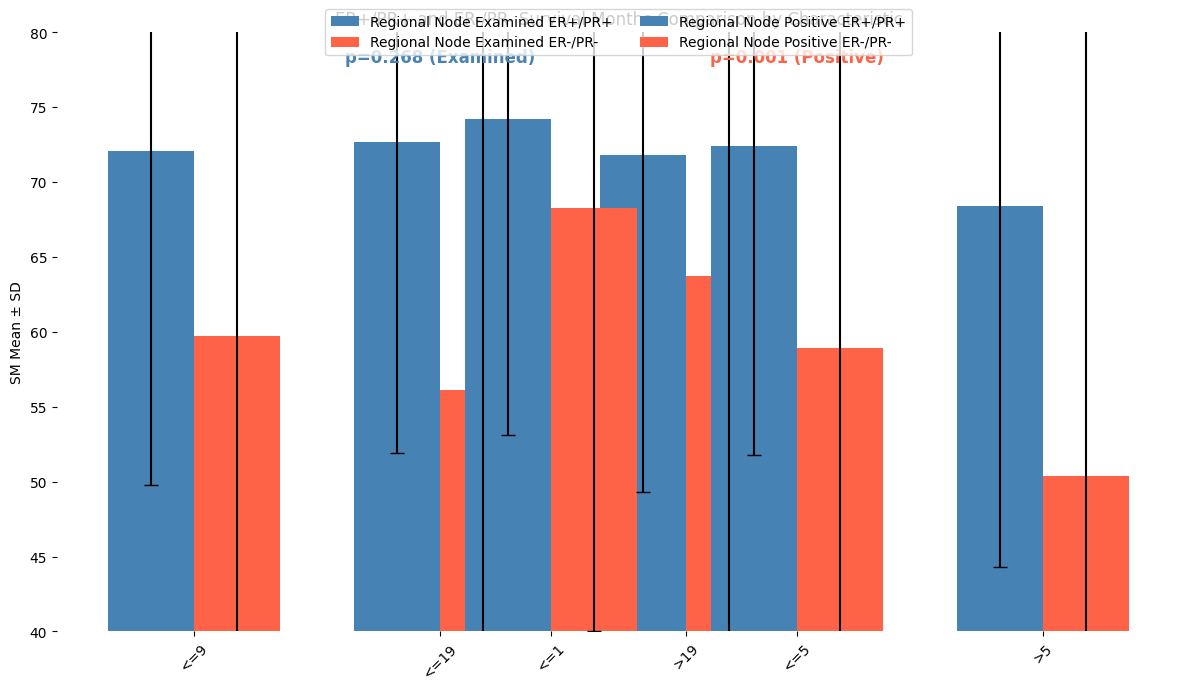

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data
data = {
    'Characteristic': ['Regional Node Examined']*3 + ['Regional Node Positive']*3 + ['Regional Node Examined']*3 + ['Regional Node Positive']*3,
    'Category': ['<=9', '<=19', '>19', '<=1', '<=5', '>5', '<=9', '<=19', '>19', '<=1', '<=5', '>5'],
    'SM_Mean': [72.1, 72.7, 71.8, 74.2, 72.4, 68.4, 59.7, 56.1, 63.7, 68.3, 58.9, 50.4],
    'SM_SD': [22.3, 20.8, 22.5, 21.1, 20.6, 24.1, 32.7, 31.2, 27.0, 28.3, 29.9, 31.2],
    'Group': ['ER+/PR+']*6 + ['ER-/PR-']*6
}

# Create DataFrame
df = pd.DataFrame(data)

# Prepare plot
fig, ax = plt.subplots(figsize=(12, 7))
categories_examined = ['<=9', '<=19', '>19']
categories_positive = ['<=1', '<=5', '>5']
x_examined = np.arange(len(categories_examined))
x_positive = np.arange(len(categories_positive))
width = 0.35

# Colors
colors = {'ER+/PR+': 'steelblue', 'ER-/PR-': 'tomato'}

# Plot Regional Node Examined
for i, group in enumerate(['ER+/PR+', 'ER-/PR-']):
    data_sub = df[(df['Characteristic'] == 'Regional Node Examined') & (df['Group'] == group)]
    ax.bar(x_examined + i*width, data_sub['SM_Mean'], width, yerr=data_sub['SM_SD'], label=f'Regional Node Examined {group}',
           color=colors[group], capsize=5)

# Position adjustment for Regional Node Positive
position_offset = len(x_examined)*width + 0.4

for i, group in enumerate(['ER+/PR+', 'ER-/PR-']):
    data_sub = df[(df['Characteristic'] == 'Regional Node Positive') & (df['Group'] == group)]
    ax.bar(x_positive + position_offset + i*width, data_sub['SM_Mean'], width, yerr=data_sub['SM_SD'],
           label=f'Regional Node Positive {group}', color=colors[group], capsize=5)

# Set x-axis
all_x = np.concatenate([x_examined, x_positive + position_offset])
all_labels = categories_examined + categories_positive
ax.set_xticks(all_x + width / 2)
ax.set_xticklabels(all_labels, rotation=45)

# Axis settings
ax.set_ylabel('SM Mean ± SD')
ax.set_ylim(40, 80)
ax.set_title('ER+/PR+ and ER-/PR- Survival Months Comparison by Characteristic')

# Remove grid and spines
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Annotate p-values
ax.text(np.mean(x_examined + width/2), 78, 'p=0.268 (Examined)', ha='center', fontsize=12, fontweight='bold', color='steelblue')
ax.text(np.mean(x_positive + position_offset + width/2), 78, 'p=0.001 (Positive)', ha='center', fontsize=12, fontweight='bold', color='tomato')

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# 간결 테이블 데이터
data = {
    'LNR Category': ['Low (≤0.2)', 'Middle (≤0.65)', 'High (>0.65)'],
    'ER+/PR+ n(%)': ['1655 (50.2%)', '1144 (34.7%)', '500 (15.2%)'],
    'ER+/PR+ SM Mean ± SD': ['74.1 ± 20.4', '71.4 ± 21.7', '68.3 ± 24.5'],
    'ER-/PR- n(%)': ['97 (40.1%)', '84 (34.7%)', '61 (25.2%)'],
    'ER-/PR- SM Mean ± SD': ['67.3 ± 26.6', '58.5 ± 31.6', '46.2 ± 31.1'],
    'Within p-value (++ / --)': ['0.000 / 0.000', '', ''],
    'Within F-value (++ / --)': ['15.3 / 9.5', '', '']
}
df = pd.DataFrame(data)

# 테이블 출력 (콘솔)
print(df.to_string(index=False))

# CSV로 저장 (논문용)
df.to_csv('summary_table.csv', index=False)


  LNR Category ER+/PR+ n(%) ER+/PR+ SM Mean ± SD ER-/PR- n(%) ER-/PR- SM Mean ± SD Within p-value (++ / --) Within F-value (++ / --)
    Low (≤0.2) 1655 (50.2%)          74.1 ± 20.4   97 (40.1%)          67.3 ± 26.6            0.000 / 0.000               15.3 / 9.5
Middle (≤0.65) 1144 (34.7%)          71.4 ± 21.7   84 (34.7%)          58.5 ± 31.6                                                  
  High (>0.65)  500 (15.2%)          68.3 ± 24.5   61 (25.2%)          46.2 ± 31.1                                                  
